# IPL Win Probability Predictor

**Goal:** given the state of a run-chase (runs needed, balls left, wickets in hand, who's
playing, where), predict the probability that the chasing team wins the match.

This notebook is built on top of the logic taught in the CampusX
["IPL Win Probability Predictor"](https://github.com/campusx-official/ipl-win-probability-predictor)
tutorial, but it is **not a copy of that code**. Their notebook was written in 2021 for an
8-team, 2008-2020 Kaggle dataset. My dataset runs 2007/08 -> 2026 and has 10 current
franchises (after renames/mergers), and the raw ball-by-ball data is structured
differently. So every step below was re-derived against *this* dataset, and a few real
bugs in the tutorial's approach were fixed along the way. Each one is called out with a
**"Why"** note when it comes up, so it's a design decision, not an accident.

**The three bugs/simplifications this notebook fixes, versus the tutorial:**
1. **Balls left was computed wrong.** A wide or no-ball gets its own row in this dataset
   but is *not* a legal delivery -- it must be re-bowled, so it should not count against
   the 120-ball quota. The tutorial's `126 - (over*6+ball)` formula silently assumes every
   row is a legal ball, which isn't true here.
2. **"Target" was off by the winning margin.** Chasing team wins by matching the
   1st-innings score +1, not by merely equalling it. Using the raw 1st-innings total as
   the target makes a tied scoreline look like `runs_left == 0`, i.e. "already won",
   which is wrong.
3. **The train/test split leaked data.** Randomly shuffling individual balls means
   consecutive balls from the *same match* can end up in both train and test. Since
   consecutive balls are nearly identical, a model can partly memorize matches instead
   of learning general chase dynamics. This inflates accuracy in a way that won't hold up
   under questioning. Section 4 shows exactly how big the inflation is.

Data files used (place them in the same folder as this notebook):
- `ipl_ball_by_ball.csv` -- one row per ball bowled
- `ipl_matches.csv` -- one row per match, used only to flag matches to exclude


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)


## 1. Load and get oriented

Before writing any feature-engineering code, it's worth just looking at what we actually
have -- column names, a few rows, and how many matches/deliveries we're working with.

In [2]:
ball_by_ball = pd.read_csv('ipl_ball_by_ball.csv', low_memory=False)
matches = pd.read_csv('ipl_matches.csv')

print('ball-by-ball rows:', ball_by_ball.shape[0], '| columns:', ball_by_ball.shape[1])
print('matches rows:', matches.shape[0])
print('season range:', sorted(matches['season'].unique())[0], '-', sorted(matches['season'].unique())[-1])
ball_by_ball.head()


ball-by-ball rows: 288226 | columns: 34
matches rows: 1212
season range: 2007/08 - 2026


,match_id,date,season,venue,city,innings,batting_team,bowling_team,over,ball_in_over,ball_number,batter,bowler,non_striker,batter_runs,extra_runs,total_runs,wides,noballs,byes,legbyes,penalty,is_wicket,wicket_player_out,wicket_kind,match_winner,toss_winner,toss_decision,team1,team2,is_powerplay,is_middle_overs,is_death_overs,batting_team_won
0,1082591,2017-04-05,2017,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,1,Sunrisers Hyderabad,Royal Challengers Bangalore,0,1,1,DA Warner,TS Mills,S Dhawan,0,0,0,0,0,0,0,0,0,NaN,NaN,Sunrisers Hyderabad,Royal Challengers Bangalore,field,Sunrisers Hyderabad,Royal Challengers Bangalore,1,0,0,1
1,1082591,2017-04-05,2017,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,1,Sunrisers Hyderabad,Royal Challengers Bangalore,0,2,2,DA Warner,TS Mills,S Dhawan,0,0,0,0,0,0,0,0,0,NaN,NaN,Sunrisers Hyderabad,Royal Challengers Bangalore,field,Sunrisers Hyderabad,Royal Challengers Bangalore,1,0,0,1
2,1082591,2017-04-05,2017,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,1,Sunrisers Hyderabad,Royal Challengers Bangalore,0,3,3,DA Warner,TS Mills,S Dhawan,4,0,4,0,0,0,0,0,0,NaN,NaN,Sunrisers Hyderabad,Royal Challengers Bangalore,field,Sunrisers Hyderabad,Royal Challengers Bangalore,1,0,0,1
3,1082591,2017-04-05,2017,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,1,Sunrisers Hyderabad,Royal Challengers Bangalore,0,4,4,DA Warner,TS Mills,S Dhawan,0,0,0,0,0,0,0,0,0,NaN,NaN,Sunrisers Hyderabad,Royal Challengers Bangalore,field,Sunrisers Hyderabad,Royal Challengers Bangalore,1,0,0,1
4,1082591,2017-04-05,2017,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,1,Sunrisers Hyderabad,Royal Challengers Bangalore,0,5,5,DA Warner,TS Mills,S Dhawan,0,2,2,2,0,0,0,0,0,NaN,NaN,Sunrisers Hyderabad,Royal Challengers Bangalore,field,Sunrisers Hyderabad,Royal Challengers Bangalore,1,0,0,1


In [3]:
matches.head()

,match_id,date,city,venue,team1,team2,toss_winner,toss_decision,winner,result_type,player_of_match,season,event_name,match_type,gender,overs,balls_per_over,team1_won,toss_winner_won
0,1082591,2017-04-05,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,"['by', 'winner']",Yuvraj Singh,2017,Indian Premier League,T20,male,20,6,1,0
1,1082592,2017-04-06,Pune,Maharashtra Cricket Association Stadium,Rising Pune Supergiant,Mumbai Indians,Rising Pune Supergiant,field,Rising Pune Supergiant,"['by', 'winner']",SPD Smith,2017,Indian Premier League,T20,male,20,6,1,1
2,1082593,2017-04-07,Rajkot,Saurashtra Cricket Association Stadium,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,Kolkata Knight Riders,"['winner', 'by']",CA Lynn,2017,Indian Premier League,T20,male,20,6,0,1
3,1082594,2017-04-08,Indore,Holkar Cricket Stadium,Kings XI Punjab,Rising Pune Supergiant,Kings XI Punjab,field,Kings XI Punjab,"['by', 'winner']",GJ Maxwell,2017,Indian Premier League,T20,male,20,6,1,1
4,1082595,2017-04-08,Bengaluru,M.Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,Royal Challengers Bangalore,"['winner', 'by']",KM Jadhav,2017,Indian Premier League,T20,male,20,6,1,1


## 2. Data cleaning

Three things need to happen before we can trust any row for training:

**a) Drop matches with no result.** 25 matches in `ipl_matches.csv` have a null `winner`
(abandoned / washed out). There's nothing to learn a win/loss label from, so these
have to go.

**b) Drop DLS (rain-rule) matches.** When the Duckworth-Lewis-Stern method is used, the
target for the chasing team is no longer simply "1st innings score + 1" -- it's a
recalculated par score that depends on overs lost. Our `runs_left`/`balls_left`
arithmetic assumes a clean 120-ball chase, so these matches would silently get the wrong
target. `ipl_matches.csv` doesn't have a clean boolean flag for this, but the
`result_type` column contains the word `'method'` whenever DLS was invoked -- so we use
that as the filter.

**c) Fix historical team identities.** The IPL has renamed/rebranded franchises several
times over its 19 seasons (e.g. Delhi Daredevils -> Delhi Capitals). If we don't merge
these, the model treats "Delhi Daredevils" and "Delhi Capitals" as two unrelated teams
and splits their history in half for no good reason. We map every old name to its
current identity, then keep only the 10 franchises that are actually playing IPL today
-- one-off/defunct teams like Kochi Tuskers Kerala or Pune Warriors add noise and will
never appear in a real prediction anyway.

In [4]:
# a) + b): figure out which match_ids to drop
no_result_ids = set(matches.loc[matches['winner'].isnull(), 'match_id'])
dls_ids = set(matches.loc[matches['result_type'].str.contains('method', na=False), 'match_id'])
exclude_ids = no_result_ids | dls_ids

print(f'no-result matches: {len(no_result_ids)}')
print(f'DLS-affected matches: {len(dls_ids)}')
print(f'total matches excluded: {len(exclude_ids)}  (out of {matches["match_id"].nunique()})')

df = ball_by_ball[~ball_by_ball['match_id'].isin(exclude_ids)].copy()


no-result matches: 25
DLS-affected matches: 22
total matches excluded: 47  (out of 1212)


In [5]:
# c) normalize franchise identities, then restrict to teams still active today
rename_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
}
for col in ['batting_team', 'bowling_team', 'team1', 'team2']:
    df[col] = df[col].replace(rename_map)

current_teams = [
    'Chennai Super Kings', 'Delhi Capitals', 'Gujarat Titans', 'Kolkata Knight Riders',
    'Lucknow Super Giants', 'Mumbai Indians', 'Punjab Kings', 'Rajasthan Royals',
    'Royal Challengers Bengaluru', 'Sunrisers Hyderabad',
]

before = df['match_id'].nunique()
df = df[df['batting_team'].isin(current_teams) & df['bowling_team'].isin(current_teams)]
print(f'matches before team filter: {before}  ->  after: {df["match_id"].nunique()}')

# also drop super-over innings (innings 3-6) -- we only model the normal 2-innings chase
df = df[df['innings'].isin([1, 2])]


matches before team filter: 1165  ->  after: 1056


### A closer look: why "balls left" can't just be `120 - ball_number`

Cricket only counts *legal* deliveries against the 6-balls-per-over quota. A wide or a
no-ball doesn't count -- the bowler has to bowl it again. Let's check whether this
dataset's per-ball numbering already accounts for that, or whether it naively counts
every row (legal or not).

In [6]:
sample_match = df[(df['match_id'] == df['match_id'].iloc[0]) & (df['innings'] == 1) & (df['over'] == 0)]
print(sample_match[['over', 'ball_in_over', 'ball_number', 'total_runs', 'wides', 'noballs']])
print()
rows_per_over = df.groupby(['match_id', 'innings', 'over']).size()
print('overs with MORE than 6 rows (because of a wide/no-ball):', (rows_per_over > 6).sum())


   over  ball_in_over  ball_number  total_runs  wides  noballs
0     0             1            1           0      0        0
1     0             2            2           0      0        0
2     0             3            3           4      0        0
3     0             4            4           0      0        0
4     0             5            5           2      2        0
5     0             6            6           0      0        0
6     0             7            7           1      0        0

overs with MORE than 6 rows (because of a wide/no-ball): 7815


Confirmed: this over has **7 rows**, not 6, because of one wide. `ball_number` just
counts rows in order -- it does not skip illegal deliveries. So if we used
`120 - ball_number` directly, every wide/no-ball bowled in a match would make us think
one fewer ball remains than actually does. Over a whole innings that can shift
`balls_left` by several balls, which then distorts `crr`/`rrr` too. We'll fix this
properly in the feature engineering step below by building our own legal-ball counter.

## 3. Feature engineering

For every ball of the 2nd innings, we want to know: at this exact moment, how much does
the chasing team need, how much time/wickets do they have left, and did they go on to
win? That row becomes one training example.

**Features:**
- `batting_team`, `bowling_team`, `city` -- categorical context
- `runs_left` -- target minus runs scored so far
- `balls_left` -- 120 minus *legal* balls bowled so far (see fix above)
- `wickets_left` -- 10 minus wickets fallen so far
- `target` -- runs the chasing team needs to reach (1st-innings score **+ 1**, not just
  the raw score -- see the note below)
- `crr` -- current run rate (runs per over, at this point in the chase)
- `rrr` -- required run rate (runs per over still needed, at this point)

**Label:** `result` -- did the batting (chasing) team end up winning.

In [7]:
# --- target: how many runs does the chasing team actually need? ---
# Why +1: matching the 1st-innings score exactly is a TIE, not a win. The chasing team
# needs to get one run ahead. If we used the raw 1st-innings total as "target", the model
# would see runs_left hit exactly 0 on a tie and think the chase was already won.
first_innings_runs = df[df['innings'] == 1].groupby('match_id')['total_runs'].sum()
target_by_match = (first_innings_runs + 1).to_dict()

second_innings = df[df['innings'] == 2].copy()
second_innings['target'] = second_innings['match_id'].map(target_by_match)

# make sure we process each match's deliveries in bowled order before doing cumulative sums
second_innings = second_innings.sort_values(['match_id', 'ball_number']).reset_index(drop=True)
print('2nd-innings rows to work with:', second_innings.shape[0])


2nd-innings rows to work with: 122649


In [8]:
# a handful of matches (all played in the UAE) have city missing but venue present --
# recover the city from the venue instead of throwing the data away
venue_to_city = {
    'Dubai International Cricket Stadium': 'Dubai',
    'Sharjah Cricket Stadium': 'Sharjah',
}
missing_before = second_innings['city'].isnull().sum()
second_innings['city'] = second_innings['city'].fillna(second_innings['venue'].map(venue_to_city))
print(f'rows with missing city: {missing_before} -> {second_innings["city"].isnull().sum()}')


rows with missing city: 5641 -> 0


In [9]:
# --- current_score & runs_left ---
second_innings['current_score'] = second_innings.groupby('match_id')['total_runs'].cumsum()
second_innings['runs_left'] = second_innings['target'] - second_innings['current_score']

# --- balls_left, done correctly this time ---
# a delivery only counts against the 120-ball quota if it's neither a wide nor a no-ball
second_innings['is_legal_ball'] = ((second_innings['wides'] == 0) & (second_innings['noballs'] == 0)).astype(int)
second_innings['legal_balls_bowled'] = second_innings.groupby('match_id')['is_legal_ball'].cumsum()
second_innings['balls_left'] = 120 - second_innings['legal_balls_bowled']

# --- wickets_left ---
# is_wicket also flags 'retired hurt' as a dismissal, which isn't strictly a wicket in the
# laws of cricket (the batter can resume later) -- but it happens 19 times in the entire
# dataset, so treating it the same as a normal dismissal is a fine simplification here.
second_innings['wickets_lost'] = second_innings.groupby('match_id')['is_wicket'].cumsum()
second_innings['wickets_left'] = 10 - second_innings['wickets_lost']

# --- run rates ---
second_innings['crr'] = (second_innings['current_score'] * 6) / second_innings['legal_balls_bowled']
second_innings['rrr'] = np.where(
    second_innings['balls_left'] > 0,
    (second_innings['runs_left'] * 6) / second_innings['balls_left'],
    np.nan,
)

# --- label ---
# the raw data already has a precomputed, verified 'batting_team_won' column -- no need
# to rebuild this ourselves from match winners
second_innings['result'] = second_innings['batting_team_won']

second_innings[['over', 'ball_in_over', 'current_score', 'runs_left', 'balls_left',
                'wickets_left', 'crr', 'rrr', 'result']].tail(8)


,over,ball_in_over,current_score,runs_left,balls_left,wickets_left,crr,rrr,result
122641,18,2,214,12,11,7,11.779817,6.545455,1
122642,17,9,215,11,10,7,11.727273,6.600000,1
122643,18,3,215,11,9,7,11.621622,7.333333,1
122644,18,4,216,10,8,7,11.571429,7.500000,1
122645,18,5,217,9,7,7,11.522124,7.714286,1
122646,18,6,221,5,6,7,11.631579,5.000000,1
122647,19,1,225,1,5,7,11.739130,1.200000,1
122648,19,2,226,0,5,7,11.791304,0.000000,1


### Cleaning up edge cases

Two things show up at the boundaries of an innings that need handling -- neither is a
data error, both are just artifacts of how a chase actually ends:

- **Negative `runs_left`**: if a team needs 2 runs and hits a six, they score more than
  strictly required. `runs_left` goes negative on that final ball. This is correct
  cricket, not a bug -- we keep these rows.
- **Infinite `crr`**: if the very *first* ball of the innings happens to be a wide,
  `legal_balls_bowled` is still 0 at that row, so `runs/0` -> infinity. This is a genuine
  edge case with only a handful of rows across the whole dataset -- we drop them.

We also drop the very last ball of any innings (`balls_left == 0`), because `rrr` is
undefined once there's no time left -- same choice the original tutorial makes.

In [10]:
final_df = second_innings[[
    'batting_team', 'bowling_team', 'city',
    'runs_left', 'balls_left', 'wickets_left', 'target', 'crr', 'rrr', 'result',
]].copy()

rows_before = final_df.shape[0]
final_df = final_df[final_df['balls_left'] > 0]
final_df = final_df.replace([np.inf, -np.inf], np.nan).dropna()
print(f'rows before edge-case cleanup: {rows_before}  ->  after: {final_df.shape[0]}')
print()
print('class balance (does the chasing team win?):')
print(final_df['result'].value_counts(normalize=True).rename('share'))
print()
final_df.describe()


rows before edge-case cleanup: 122649  ->  after: 122183

class balance (does the chasing team win?):
result
1    0.518738
0    0.481262
Name: share, dtype: float64



,runs_left,balls_left,wickets_left,target,crr,rrr,result
count,122183.000000,122183.000000,122183.000000,122183.000000,122183.000000,122183.000000,122183.000000
mean,96.265119,62.978393,7.503343,172.553874,7.843435,10.971465,0.518738
std,51.891917,33.219170,2.161333,32.311799,2.530150,13.424265,0.499651
min,-5.000000,1.000000,0.000000,68.000000,0.000000,-30.000000,0.000000
25%,55.000000,35.000000,6.000000,152.000000,6.518519,7.378378,0.000000
50%,95.000000,64.000000,8.000000,172.000000,7.800000,9.171429,1.000000
75%,135.000000,92.000000,9.000000,193.000000,9.135749,11.425809,1.000000
max,287.000000,119.000000,10.000000,288.000000,60.000000,714.000000,1.000000


## 4. The train/test split matters more than the model choice

Here's the part that's easy to get wrong (and the original tutorial does get wrong):
`final_df.sample()` followed by a plain `train_test_split` shuffles **individual balls**,
not matches. Ball 51 of a match can land in the training set while ball 52 of the *same
match* lands in the test set. Since two consecutive balls of the same chase are almost
identical (same teams, same city, runs/wickets barely changed), a flexible enough model
can partially memorize matches rather than learn general chase dynamics -- and the
reported accuracy won't reflect how well it'll do on a genuinely new match.

The fix: split by **match**, not by row -- every ball from a given match goes entirely
into train or entirely into test.

Let's actually measure the damage this causes.

In [11]:
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

feature_cols = ['batting_team', 'bowling_team', 'city', 'runs_left', 'balls_left',
                'wickets_left', 'target', 'crr', 'rrr']

# keep match_id alongside the features (only used for the grouped split, never fed to the model)
X = second_innings.loc[final_df.index, feature_cols + ['match_id']]
y = final_df['result']

# NOTE on OneHotEncoder args, since the reference tutorial's code will not even run on a
# current scikit-learn install:
#   - `sparse=False` was removed years ago; the current spelling is `sparse_output=False`
#   - `handle_unknown='ignore'` matters once we split by match: a rare city might only
#     appear in the test fold, and without this the encoder would crash at predict time
preprocessor = ColumnTransformer([
    ('one_hot', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'),
     ['batting_team', 'bowling_team', 'city']),
], remainder='passthrough')

def make_pipeline(model):
    return Pipeline([('prep', preprocessor), ('model', model)])

def evaluate(name, pipe, X_train, X_test, y_train, y_test):
    pipe.fit(X_train[feature_cols], y_train)
    preds = pipe.predict(X_test[feature_cols])
    probs = pipe.predict_proba(X_test[feature_cols])[:, 1]
    print(f'{name:32s} accuracy={accuracy_score(y_test, preds):.4f}   '
          f'log-loss={log_loss(y_test, probs):.4f}   brier={brier_score_loss(y_test, probs):.4f}')


In [12]:
print('=== naive split: individual balls shuffled at random ===')
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=1)
evaluate('Logistic Regression', make_pipeline(LogisticRegression(solver='liblinear')), Xtr, Xte, ytr, yte)
evaluate('Random Forest', make_pipeline(RandomForestClassifier(n_estimators=200, random_state=1, n_jobs=-1)), Xtr, Xte, ytr, yte)


=== naive split: individual balls shuffled at random ===
Logistic Regression              accuracy=0.7979   log-loss=0.4138   brier=0.1351
Random Forest                    accuracy=0.9978   log-loss=0.0416   brier=0.0056


In [13]:
print('=== proper split: every match goes entirely to train OR entirely to test ===')
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=1)
train_idx, test_idx = next(splitter.split(X, y, groups=X['match_id']))
Xtr, Xte = X.iloc[train_idx], X.iloc[test_idx]
ytr, yte = y.iloc[train_idx], y.iloc[test_idx]
print(f'train matches: {Xtr["match_id"].nunique()}   test matches: {Xte["match_id"].nunique()}')
print()
evaluate('Logistic Regression', make_pipeline(LogisticRegression(solver='liblinear')), Xtr, Xte, ytr, yte)
evaluate('Random Forest', make_pipeline(RandomForestClassifier(n_estimators=200, random_state=1, n_jobs=-1)), Xtr, Xte, ytr, yte)
evaluate('Random Forest (max_depth=12)', make_pipeline(RandomForestClassifier(n_estimators=300, max_depth=12, random_state=1, n_jobs=-1)), Xtr, Xte, ytr, yte)


=== proper split: every match goes entirely to train OR entirely to test ===
train matches: 844   test matches: 212

Logistic Regression              accuracy=0.7641   log-loss=0.4758   brier=0.1561
Random Forest                    accuracy=0.7430   log-loss=0.5047   brier=0.1684
Random Forest (max_depth=12)     accuracy=0.7592   log-loss=0.4751   brier=0.1563


**What happened:** under the naive split, Random Forest looks almost perfect
(~99.8% accuracy) -- that's the leakage, not genuine skill. Once matches are kept whole,
Random Forest's honest accuracy drops back down to a realistic range, and in this
dataset it actually performs about the same as -- or slightly worse than -- plain
Logistic Regression, once the forest's depth is reasonably limited to stop it from
over-fitting to the training matches.

**Model choice:** given Logistic Regression matches or beats a much heavier Random
Forest under a fair evaluation, and it's simpler, faster, and its probabilities are
naturally better-behaved (see the calibration check below), it's the more defensible
choice here. This also happens to be the tutorial's final choice -- but for a
demonstrated reason now, not by default.

## 5. Is the probability actually trustworthy?

Accuracy only tells us whether the top guess was right. Since the whole point here is a
*probability*, not just a label, it's worth checking calibration: when the model says
"70% chance to win", do teams in that bucket actually win about 70% of the time?

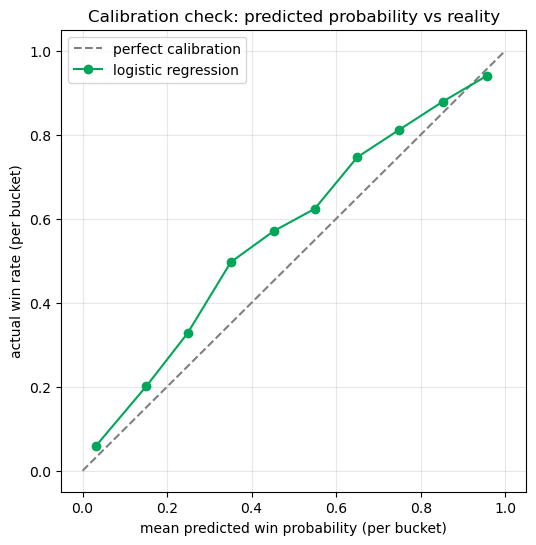

In [14]:
from sklearn.calibration import calibration_curve

final_pipe = make_pipeline(LogisticRegression(solver='liblinear'))
final_pipe.fit(Xtr[feature_cols], ytr)
test_probs = final_pipe.predict_proba(Xte[feature_cols])[:, 1]

actual_rate, predicted_rate = calibration_curve(yte, test_probs, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='perfect calibration')
plt.plot(predicted_rate, actual_rate, marker='o', color='#00a65a', label='logistic regression')
plt.xlabel('mean predicted win probability (per bucket)')
plt.ylabel('actual win rate (per bucket)')
plt.title('Calibration check: predicted probability vs reality')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


The curve sits close to the diagonal -- when the model says "around 65% to win",
the chasing team wins roughly that often in the held-out matches. It's not perfect (it's
a little conservative in the 30-55% range), but it's reasonable enough to actually call
this a *probability* rather than just a confidence score.

## 6. Watching a real chase unfold

The most intuitive way to sanity-check this model is to pick one held-out match and
watch the predicted win probability move, over-by-over, and compare it against what
actually happened in that game.

In [15]:
def match_progression(match_id, source_df, pipe):
    """Returns the model's win-probability read at the end of every completed over
    of a given match's chase, plus some context to make the story readable."""
    match_rows = source_df[source_df['match_id'] == match_id]
    end_of_over = match_rows.groupby('over').tail(1)  # state at the last ball of each over
    probs = pipe.predict_proba(end_of_over[feature_cols])[:, 1]

    progression = pd.DataFrame({
        'over': end_of_over['over'].values + 1,
        'runs_left': end_of_over['runs_left'].values,
        'wickets_left': end_of_over['wickets_left'].values,
        'win_probability_%': np.round(probs * 100, 1),
    })
    context = {
        'batting_team': end_of_over['batting_team'].iloc[0],
        'bowling_team': end_of_over['bowling_team'].iloc[0],
        'target': int(end_of_over['target'].iloc[0]),
    }
    return progression, context

# pick a test-set match we haven't trained on
sample_match_id = Xte['match_id'].iloc[0]
progression, context = match_progression(sample_match_id, second_innings, final_pipe)
print(f"{context['batting_team']} chasing {context['target']} against {context['bowling_team']}")
progression


Delhi Capitals chasing 130 against Rajasthan Royals


,over,runs_left,wickets_left,win_probability_%
0,1,122,10,78.6
1,2,109,9,79.2
2,3,104,9,79.4
3,4,94,9,84.1
4,5,82,9,89.1
5,6,75,9,90.6
6,7,71,9,90.6
7,8,59,9,94.0
8,9,52,9,95.0
9,10,44,9,96.2


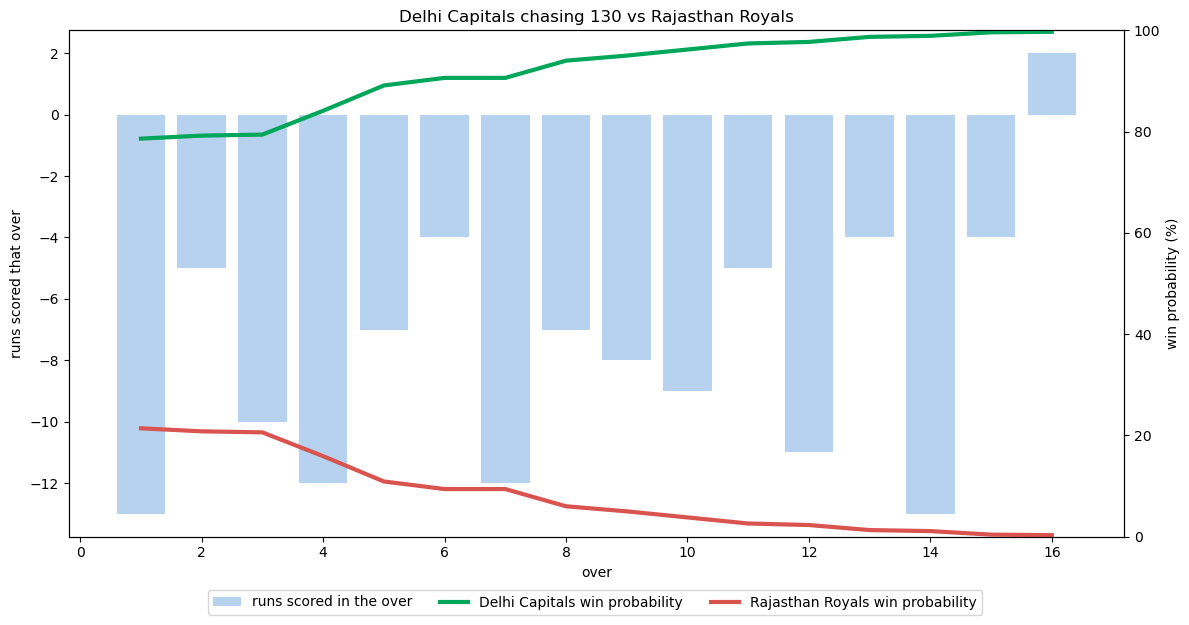

In [16]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(progression['over'], progression['runs_left'].diff(-1).fillna(progression['runs_left'].iloc[-1]) * -1,
        color='#4a90d9', alpha=0.4, label='runs scored in the over')
ax1.set_xlabel('over')
ax1.set_ylabel('runs scored that over')

ax2 = ax1.twinx()
ax2.plot(progression['over'], progression['win_probability_%'], color='#00a65a', linewidth=3,
         label=f"{context['batting_team']} win probability")
ax2.plot(progression['over'], 100 - progression['win_probability_%'], color='#d9534f', linewidth=3,
         label=f"{context['bowling_team']} win probability")
ax2.set_ylabel('win probability (%)')
ax2.set_ylim(0, 100)

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=3)
plt.title(f"{context['batting_team']} chasing {context['target']} vs {context['bowling_team']}")
plt.tight_layout()
plt.show()


This is the same kind of chart the reference tutorial builds at the end of its
notebook -- but here it's driven by a model that was actually evaluated on matches it
never trained on, so the shape of this curve reflects genuine chase dynamics rather than
memorized outcomes.

## 7. Refit on everything and save

The comparisons above used a held-out test set on purpose, to get an honest read on
performance. Now that we've picked Logistic Regression and understand its behaviour,
the last step is to refit it on *all* the cleaned data (train + test combined) so the
saved model has seen as much cricket as possible before being used for real predictions.

In [17]:
import pickle

production_pipe = make_pipeline(LogisticRegression(solver='liblinear'))
production_pipe.fit(X[feature_cols], y)

with open('ipl_win_predictor_pipeline.pkl', 'wb') as f:
    pickle.dump(production_pipe, f)

print('saved ipl_win_predictor_pipeline.pkl')
print('trained on', X.shape[0], 'deliveries across', X['match_id'].nunique(), 'matches')


saved ipl_win_predictor_pipeline.pkl
trained on 122183 deliveries across 1056 matches


## 8. A simple "what-if" helper

This mirrors what the reference tutorial's Streamlit app does with manual number inputs
-- useful for plugging in a live match situation by hand and getting an instant read,
without needing the full ball-by-ball dataset in front of you.

In [22]:
def predict_win_probability(batting_team, bowling_team, city, target, score, overs_completed, wickets_out):
    """
    overs_completed: overs completed as a decimal, e.g. 14.3 means 14 overs + 3 balls
    wickets_out: how many wickets the batting team has already lost
    """
    completed_overs_int = int(overs_completed)
    balls_in_current_over = round((overs_completed - completed_overs_int) * 10)
    legal_balls_bowled = completed_overs_int * 6 + balls_in_current_over

    runs_left = target - score
    balls_left = 120 - legal_balls_bowled
    wickets_left = 10 - wickets_out
    crr = (score * 6) / legal_balls_bowled if legal_balls_bowled > 0 else 0
    rrr = (runs_left * 6) / balls_left if balls_left > 0 else 0

    row = pd.DataFrame([{
        'batting_team': batting_team, 'bowling_team': bowling_team, 'city': city,
        'runs_left': runs_left, 'balls_left': balls_left, 'wickets_left': wickets_left,
        'target': target, 'crr': crr, 'rrr': rrr,
    }])
    win_prob = production_pipe.predict_proba(row)[0, 1]
    print(f'{batting_team}: {win_prob*100:.1f}%   |   {bowling_team}: {(1-win_prob)*100:.1f}%')
    return win_prob

# example: chasing 176, currently 120/4 after 15 overs
_ = predict_win_probability(
    batting_team='Chennai Super Kings', bowling_team='Mumbai Indians', city='Chennai',
    target=176, score=120, overs_completed=15.0, wickets_out=4,
)


Chennai Super Kings: 30.4%   |   Mumbai Indians: 69.6%


## Limitations and honest next steps

Worth knowing about, even though none of these were worth solving for a first version:

- **Tied matches decided by Super Over**: a handful of matches in the data end level
  after 20 overs and get decided in a Super Over. The label for those matches'
  2nd-innings balls reflects the eventual Super Over winner, which the model can't see
  coming from the normal-innings state. This affects a very small number of matches
  (well under 2% of the dataset) so it's negligible here, but it's a known source of
  label noise, not an oversight.
- **No player-specific skill features.** The model only sees match state (score,
  wickets, run rates), not *who* is at the crease or bowling. Two teams with identical
  runs/wickets/overs can have very different real chances depending on which batters are
  still in -- that's out of scope for this version but would be the natural next feature
  to add (e.g. average strike rate of remaining batters).
- **Venue/city as a blunt proxy for pitch conditions.** City captures some ground effect
  (e.g. Chepauk pitches favour spin) but a `venue`-level feature would be more precise
  than `city`, at the cost of more categories with less data each.
- **Retired hurt is treated as a normal dismissal** (see Section 3) -- correct often
  enough to not matter here, but not strictly accurate to the laws of cricket.


In [19]:
import pickle

# Open the pickle file in 'rb' (read binary) mode
with open('ipl_win_predictor_pipeline.pkl', 'rb') as file:
    loaded_project_object = pickle.load(file)

print("Pickle file loaded successfully!")
print("Object type:", type(loaded_project_object))

Pickle file loaded successfully!
Object type: <class 'sklearn.pipeline.Pipeline'>


In [20]:
import pandas as pd

# 1. Create a dictionary with sample match data.
# Note: You MUST change these column names to match exactly what your project uses!
sample_input = {
    'batting_team': ['Royal Challengers Bengaluru'],
    'bowling_team': ['Mumbai Indians'],
    'city': ['Mumbai'],
    'runs_left': [45],
    'balls_left': [18],
    'wickets_left': [5],
    'total_runs_x': [180],
    'crr': [7.5],
    'rrr': [15.0]
}

# 2. Convert the dictionary into a Pandas DataFrame
input_df = pd.DataFrame(sample_input)

# 3. Predict the probabilities (Win vs. Lose)
# This outputs a list like [[loss_probability, win_probability]]
probabilities = loaded_project_object.predict_proba(input_df)

# 4. Display the results nicely
win_prob = probabilities[0][1] * 100
loss_prob = probabilities[0][0] * 100

print(f"Win Probability: {win_prob:.2f}%")
print(f"Loss Probability: {loss_prob:.2f}%")

ValueError: columns are missing: {'target'}